# 07 — Paper Figures (from exports)

Builds the **final thesis figures** exclusively from the `.npz` files in
`results/` (written by notebooks 01–06). No raw data, no reprocessing — the
same pattern as `paper_plots_from_exports.ipynb`.

Rules:
- **No titles on figures** — `paper.caption_note(...)` prints the caption
  text below the cell instead.
- All cosmetic control in one place: `paper.STYLE` (global) +
  `paper.style_axis(ax, xlabel=…, xlim=…, ylim=…)` per axis. `style_axis`
  also turns the grid on (`paper.STYLE['grid']`).
- Configuration markers go through `paper.config_point(...)`: colour = cable,
  shape = gap, filled + black edge + transparency = taut, open = intended sag.
  `paper.config_handles()` returns the matching legend handles.
- `paper.save_paper_fig(fig, 'name')` writes PNG + PDF to `Figures_paper/`.

Prerequisite exports:

| File | From notebook |
|---|---|
| `geometry_sag.npz`, `geometry_views.npz` | 01 |
| `timedomain_example.npz` | 02 |
| `freqdomain_eta.npz`, `freqdomain_frf.npz` | 03 |
| `amplitude_reference.npz`, `asymmetry.npz` | 04 |
| `modal_summary.npz` | 05 |
| `linearity_eta.npz` | 06 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%load_ext autoreload
%autoreload 2

from ldv_analysis import paper
from ldv_analysis.export import load_results, list_exports
from ldv_analysis.config import CABLE_COLORS, GAP_MARKERS

# Global style — tweak here (sizes, fonts, output formats) and re-run all.
paper.apply_paper_style({
    # 'label_fs': 11,
    # 'formats': ('png', 'pdf', 'svg'),
})

list_exports()

  amplitude_reference.npz             exported 2026-07-15T00:19:08
  asymmetry.npz                       exported 2026-07-15T00:19:08
  freqdomain_eta.npz                  exported 2026-07-15T00:17:58
  freqdomain_frf.npz                  exported 2026-07-15T00:17:59
  geometry_sag.npz                    exported 2026-07-15T00:15:11
  linearity_eta.npz                   exported 2026-07-15T10:19:10
  modal_summary.npz                   exported 2026-07-15T10:16:28
  timedomain_example.npz              exported 2026-07-15T00:16:07


[WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/amplitude_reference.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/asymmetry.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/freqdomain_eta.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/freqdomain_frf.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/geometry_sag.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/linearity_eta.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/modal_summary.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS

---
## Fig. A — η vs Θ (all configurations)

Coherence-gated quasi-static band mean of |H_η| against the sag-based Θ,
with the analytical curve η = 1/(1+Θ). Colour = cable, marker = gap,
open = intended-sag variant. Vertical bars = spread of |H_η| across the
coherent bins; horizontal bars = Θ uncertainty propagated from the sag
fit residual.

In [ ]:
d   = load_results('freqdomain_eta')
geo = load_results('geometry_sag')          # sag + its fit residual

# Θ_sag = A·w₀²/(8I) is quadratic in the sag, so the sag uncertainty σ_w₀ (RMS
# residual of the constrained parabola fit, notebook 01) is propagated exactly
# through the square, Θ± = Θ·(1 ± σ_w₀/w₀)². This is asymmetric and stays
# strictly positive — the linearised σ_Θ = 2Θ·σ_w₀/w₀ would push the lower end
# below zero (σ_w₀/w₀ reaches 0.6 here) and is unusable on a log axis. The two
# exports are matched by label rather than by row order.
geo_row = {str(l): j for j, l in enumerate(geo['labels'])}
theta_err = np.full((2, len(d['labels'])), np.nan)   # rows: lower, upper
for i, lbl in enumerate(d['labels']):
    j = geo_row.get(str(lbl))
    if j is None or not geo['sag'][j] > 0:
        continue
    rel = geo['sag_rms_residual'][j] / geo['sag'][j]
    th = d['theta_sag'][i]
    theta_err[0, i] = th - th * max(1.0 - rel, 0.0) ** 2
    theta_err[1, i] = th * (1.0 + rel) ** 2 - th

fig, ax = paper.paper_figure(width='full', height=3.9)

theta   = d['theta_sag']
eta     = d['eta_h1'] * 100.0
eta_std = d['eta_h1_std'] * 100.0

x_th = np.logspace(np.log10(max(theta.min(), 1e-6)), np.log10(theta.max()), 200)
ax.plot(x_th, 100.0 / (1.0 + x_th), 'k-', lw=1.6, zorder=2,
        label=r'theory $\eta = 1/(1+\Theta)$')
ax.axvline(1 / 32, color='gray', ls=':', lw=1.0, zorder=1,
           label=r'$\Theta = 1/32$  ($w_0 = r/4$)')

for i in range(len(d['labels'])):
    paper.config_point(
        ax, theta[i], eta[i],
        cable=str(d['cable'][i]), gap_m=float(d['gap_m'][i]),
        is_sag=bool(d['is_sag_variant'][i]),
        xerr=theta_err[:, i:i + 1] if np.isfinite(theta_err[0, i]) else None,
        yerr=eta_std[i])

paper.style_axis(ax, xlabel=r'$\Theta$',
                 ylabel='strain transfer efficiency [%]',
                 xscale='log', ylim=(-5, 130))

cable_h, gap_h, sag_h = paper.config_handles()
theory_h = ax.get_legend_handles_labels()[0]
leg = ax.legend(handles=cable_h, title='cable', fontsize=7, title_fontsize=7,
                loc='lower left', frameon=False, ncol=2, handletextpad=0.3,
                columnspacing=1.0)
ax.add_artist(leg)
ax.legend(handles=gap_h + sag_h + theory_h, fontsize=7, loc='upper right',
          frameon=False, handletextpad=0.4)

paper.save_paper_fig(fig, 'eta_vs_theta')
paper.caption_note(
    f"Measured quasi-static strain-transfer efficiency (band "
    f"{d['meta']['band'][0]:.0f}-{d['meta']['band'][1]:.0f} Hz, coherence-"
    f"gated H1 estimate) against the sag parameter Theta, with the "
    f"analytical prediction 1/(1+Theta). Vertical bars: std of |H_eta| over "
    f"the coherent bins; horizontal bars: sag-residual uncertainty "
    f"propagated through Theta(w0) as Theta*(1 +- sigma_w0/w0)^2.")

---
## Fig. B — Strain-transfer FRF (four-panel, wrapped phase)

Rebuilt from the exported FRF curves of the datasets selected in notebook 03
§ 1. Low-coherence bins are drawn faint.

c:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Experiment2\Analysis_v2\ldv_analysis\paper.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: frf_four_panel.png, frf_four_panel.pdf
[caption] Measured FRFs: midpoint bending response (a, b) and strain transfer (c, d); wrapped phase; faint = coherence below the gate; dotted verticals = identified resonance f1; dashed = quasi-static 1/(1+Theta).


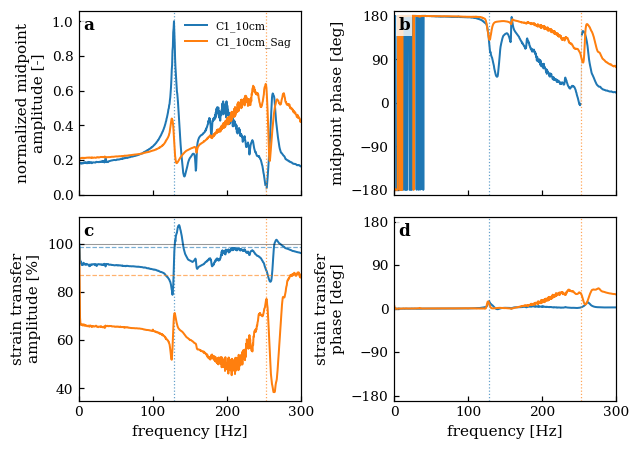

In [3]:
d = load_results('freqdomain_frf')
COH_GATE = d['meta'].get('coh_thresh', 0.7)
F_MAX = 300.0                      # <- x-limit control

f = d['f']
band = (f > 0) & (f <= F_MAX)
fb = f[band]

fig, axes = paper.paper_figure(2, 2, width='full', height=4.6, sharex=True,
                               gridspec_kw={'hspace': 0.12, 'wspace': 0.42})
(ax_a, ax_b), (ax_c, ax_d) = axes

norm = np.nanmax(d['H_mid_abs'][:, band])
for i, lbl in enumerate(d['labels']):
    col = 'C%d' % (i % 10)
    good_m = d['coh_mid'][i, band] >= COH_GATE
    good_e = d['coh_eta'][i, band] >= COH_GATE

    amp_m = d['H_mid_abs'][i, band] / norm
    ax_a.plot(fb, amp_m, color='0.85', lw=0.6)
    ax_a.plot(fb, np.where(good_m, amp_m, np.nan), color=col, lw=1.3,
              label=str(lbl))

    ph_m = np.degrees(d['H_mid_phase'][i, band])
    ax_b.plot(fb, ph_m, color='0.85', lw=0.6)
    ax_b.plot(fb, np.where(good_m, ph_m, np.nan), color=col, lw=1.3)

    amp_e = d['H_eta_abs'][i, band] * 100.0
    ax_c.plot(fb, amp_e, color='0.85', lw=0.6)
    ax_c.plot(fb, np.where(good_e, amp_e, np.nan), color=col, lw=1.3)
    ax_c.axhline(d['eta_pred'][i] * 100.0, color=col, ls='--', lw=0.8,
                 alpha=0.6)

    ph_e = np.degrees(d['H_eta_phase'][i, band])
    ax_d.plot(fb, ph_e, color='0.85', lw=0.6)
    ax_d.plot(fb, np.where(good_e, ph_e, np.nan), color=col, lw=1.3)

    if d['f1_meas'][i] <= F_MAX:
        for ax in (ax_a, ax_b, ax_c, ax_d):
            ax.axvline(d['f1_meas'][i], color=col, ls=':', lw=0.8, alpha=0.7)

ax_c.axhline(100, color='k', lw=0.7, alpha=0.4)
paper.style_axis(ax_a, ylabel='normalized midpoint\namplitude [-]',
                 xlim=(0, F_MAX), ylim=(0, 1.06))
paper.style_axis(ax_b, ylabel='midpoint phase [deg]', ylim=(-190, 190))
paper.style_axis(ax_c, xlabel='frequency [Hz]',
                 ylabel='strain transfer\namplitude [%]')
paper.style_axis(ax_d, xlabel='frequency [Hz]',
                 ylabel='strain transfer\nphase [deg]', ylim=(-190, 190))
for ax, letter in zip((ax_a, ax_b, ax_c, ax_d), 'abcd'):
    paper.panel_label(ax, letter, boxed=True)
ax_a.legend(fontsize=7, frameon=False, loc='upper right')
for ax in (ax_b, ax_d):
    ax.set_yticks([-180, -90, 0, 90, 180])

paper.save_paper_fig(fig, 'frf_four_panel')
paper.caption_note(
    'Measured FRFs: midpoint bending response (a, b) and strain transfer '
    '(c, d); wrapped phase; faint = coherence below the gate; dotted '
    'verticals = identified resonance f1; dashed = quasi-static 1/(1+Theta).')

---
## Fig. C — FRF estimator comparison (H1 / H2 / Hv / coherence)

Processing-chapter figure: the estimators only separate where the coherence
drops.

saved: estimator_comparison.png, estimator_comparison.pdf
[caption] FRF estimator comparison for C1_10cm: H1, H2 and Hv bracket the true FRF; their separation grows where the coherence (bottom) drops.


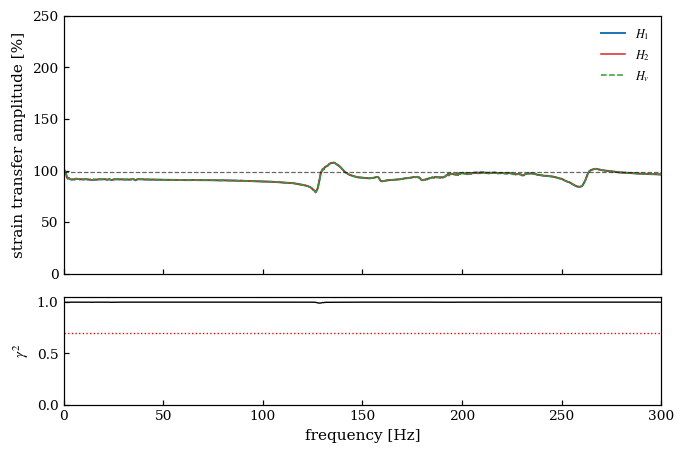

In [4]:
d = load_results('freqdomain_frf')
IDX = 0                                   # dataset row in the export
F_MAX = 300.0

f = d['f']
band = (f > 0) & (f <= F_MAX)
fb = f[band]

fig, (ax1, ax2) = paper.paper_figure(2, 1, width='full', height=4.2,
                                     sharex=True,
                                     gridspec_kw={'height_ratios': [2.4, 1.0]})
ax1.plot(fb, d['H_eta_abs'][IDX, band] * 100, color='C0', lw=1.3,
         label=r'$H_1$')
ax1.plot(fb, d['H_eta_h2_abs'][IDX, band] * 100, color='C3', lw=1.0,
         label=r'$H_2$')
ax1.plot(fb, d['H_eta_hv_abs'][IDX, band] * 100, color='C2', lw=1.0, ls='--',
         label=r'$H_v$')
ax1.axhline(d['eta_pred'][IDX] * 100, color='k', ls='--', lw=0.8, alpha=0.6)
ax2.plot(fb, d['coh_eta'][IDX, band], color='k', lw=0.9)
ax2.axhline(0.7, color='r', ls=':', lw=0.9)

paper.style_axis(ax1, ylabel='strain transfer amplitude [%]',
                 ylim=(0, 250), legend=True)
paper.style_axis(ax2, xlabel='frequency [Hz]', ylabel=r'$\gamma^2$',
                 xlim=(0, F_MAX), ylim=(0, 1.05))

paper.save_paper_fig(fig, 'estimator_comparison')
paper.caption_note(
    f"FRF estimator comparison for {d['labels'][IDX]}: H1, H2 and Hv "
    'bracket the true FRF; their separation grows where the coherence '
    '(bottom) drops.')

---
## Fig. D — Measured vs theoretical sag

In [ ]:
d = load_results('geometry_sag')

fig, ax = paper.paper_figure(width='half', height=3.4)
MS = 4.2                                    # half-width canvas -> smaller markers

lims = np.array([1e-6, 1e2])
ax.plot(lims, lims, 'k-', lw=1.0, zorder=1, label='1:1 (tension-free)')

for i in range(len(d['labels'])):
    paper.config_point(ax, d['sag_theory_tension_free'][i] * 1e3,
                       d['sag'][i] * 1e3,
                       yerr=d['sag_rms_residual'][i] * 1e3,
                       cable=str(d['cable'][i]), gap_m=float(d['gap_m'][i]),
                       is_sag=bool(d['is_sag_variant'][i]), size=MS)

paper.style_axis(ax, xlabel='tension-free theoretical sag [mm]',
                 ylabel='measured sag [mm]',
                 xscale='log', yscale='log',
                 xlim=(1e-6, 1e1), ylim=(1e-2, 1e1))

cable_h, gap_h, sag_h = paper.config_handles(size=MS)
line_h = ax.get_legend_handles_labels()[0][:1]          # the 1:1 line
leg = ax.legend(handles=cable_h, title='cable', fontsize=6, title_fontsize=6,
                loc='upper left', frameon=False, ncol=4, handletextpad=0.2,
                columnspacing=0.6, borderpad=0.2)
ax.add_artist(leg)
ax.legend(handles=gap_h + sag_h + line_h, fontsize=6, loc='lower right',
          frameon=False, handletextpad=0.3, borderpad=0.2)

paper.save_paper_fig(fig, 'sag_measured_vs_theory')
paper.caption_note(
    'Measured midpoint sag (parabola fit; error bars = RMS fit residual) '
    'against the tension-free analytical sag rho*A*g*L^4/(4 pi^4 EI). '
    'Points below the 1:1 line indicate residual pretension.')

---
## Fig. E — Time-domain example window

How η is measured: reference elongation vs cable elongation (three strain
methods — M1 arc-length, M2 gradient, M3 Fourier) in one ±N-cycle window.

In [ ]:
d = load_results('timedomain_example')
meta = d['meta']

# The M1/M2 swap changed what delta_xl_m1/m2 mean. An export written before the
# swap has the same key names with the opposite meaning, which would plot
# silently-wrong traces — so require the stamp that notebook 02 now writes.
if meta.get('strain_naming') != 'm1=arclength,m2=gradient,m3=fourier':
    raise RuntimeError(
        'timedomain_example.npz predates the M1/M2 rename (M1 is now the '
        'arc-length estimator). Re-run 02_TimeDomain_QC § 5 to regenerate it.')

fig, (ax1, ax2) = paper.paper_figure(2, 1, width='full', height=4.0,
                                     sharex=True)
t = d['t'] - d['t'][0]
ax1.plot(t, d['delta_ends'] * 1e6, color='k', lw=1.0,
         label=r'$\Delta u_\mathrm{ends}$ (reference)')
ax1.plot(t, d['delta_xl_m1'] * 1e6, color='C0', lw=1.0,
         label=r'$\delta x_\ell$ (M1 arc-length)')
ax1.plot(t, d['delta_xl_m2'] * 1e6, color='C2', lw=0.8, ls='--',
         label=r'$\delta x_\ell$ (M2 gradient)')
ax1.plot(t, d['delta_xl_m3'] * 1e6, color='C3', lw=0.8, ls=':',
         label=r'$\delta x_\ell$ (M3 Fourier)')

ax2.plot(t, d['eta_t_ends'], color='C0', lw=0.9, label=r'$\eta(t)$ (M1)')
ax2.axhline(meta['eta_med_ends'], color='k', ls='--', lw=0.9,
            label=f"median η = {meta['eta_med_ends']:.2f}")
ax2.axhline(meta['eta_pred'], color='gray', ls=':', lw=0.9,
            label=f"η_pred = {meta['eta_pred']:.2f}")

paper.style_axis(ax1, ylabel='elongation [µm]', legend=True)
paper.style_axis(ax2, xlabel='time in window [s]', ylabel='η(t)',
                 ylim=(0, 2), legend=True)
paper.panel_label(ax1, 'a'); paper.panel_label(ax2, 'b')

paper.save_paper_fig(fig, 'timedomain_example_window')
paper.caption_note(
    f"Example window ({meta['label']}, {meta['f_target']} Hz, bandpass "
    f"{meta['f_lo']:.1f}-{meta['f_hi']:.1f} Hz): (a) reference elongation "
    'and cable elongation from the three strain methods; (b) instantaneous '
    'efficiency and its median.')

---
## Fig. F — Amplitude overview (endpoint strain, band mean)

One point per configuration, grouped by cable. The x axis only carries the
cable id — gap and sag state are read off the marker via the legend.

In [ ]:
d = load_results('amplitude_reference')
f = d['f']
FMIN, FMAX = d['meta']['band']
m = (f >= FMIN) & (f <= FMAX)

# Sort into contiguous per-cable blocks (C1…C7), each ordered by gap then sag.
order = sorted(range(len(d['labels'])),
               key=lambda i: (str(d['cable'][i]), float(d['gap_m'][i]),
                              bool(d['is_sag_variant'][i])))

fig, ax = paper.paper_figure(width='full', height=3.2)
for pos, i in enumerate(order):
    vals = d['strain_ends'][i, m] * 1e6
    paper.config_point(ax, pos, np.nanmean(vals), yerr=np.nanstd(vals),
                       cable=str(d['cable'][i]), gap_m=float(d['gap_m'][i]),
                       is_sag=bool(d['is_sag_variant'][i]))

# One tick per cable at the centre of its block, thin separators in between.
cables = [str(d['cable'][i]) for i in order]
ticks, edges = [], []
for name in sorted(set(cables)):
    blk = [p for p, c in enumerate(cables) if c == name]
    ticks.append((name, 0.5 * (blk[0] + blk[-1])))
    edges.append(blk[-1] + 0.5)
for e in edges[:-1]:
    ax.axvline(e, color='0.85', lw=0.6, zorder=0)
ax.set_xticks([p for _, p in ticks])
ax.set_xticklabels([n for n, _ in ticks])

paper.style_axis(ax, ylabel=r'$\varepsilon_\mathrm{ends}$ [µε]',
                 yscale='log', xlim=(-1, len(order)))
ax.xaxis.grid(False)                        # blocks are marked by the separators

_, gap_h, sag_h = paper.config_handles()
ax.legend(handles=gap_h + sag_h, fontsize=7, frameon=False, ncol=6,
          loc='upper center', bbox_to_anchor=(0.5, 1.14),
          columnspacing=1.0, handletextpad=0.3)

paper.save_paper_fig(fig, 'amplitude_strain_overview')
paper.caption_note(
    f'Band-mean endpoint strain ({FMIN:.0f}-{FMAX:.0f} Hz) per '
    'configuration, grouped by cable; marker shape = mounting gap, open '
    'markers = intended-sag variants; error bars = std across band '
    'frequencies.')

---
## Fig. G — Static geometry of selected cables

Side (x–z) and top (x–y) view of the hanging span for the configurations
exported in notebook 01 § 7, with the chord, the constrained parabola fit and
its vertex w₀. All panels share one transverse scale, so the sag of different
cables is directly comparable.

In [ ]:
d = load_results('geometry_views')

configs = []
for k, r in enumerate(d['meta']['configs']):
    tag = f"{r['cable']}, {r['gap_cm']} cm" + (' (sag)' if r['is_sag_variant'] else '')
    configs.append(dict(label=tag, cable=r['cable'],
                        xyz=d[f'xyz_{k}'], fit=d[f'fit_{k}'],
                        w0_point=d[f'w0_{k}'],
                        sag=r['sag'], theta=r['theta']))

fig, axes = paper.geometry_views(configs, views=('side', 'top'),
                                 width='full', height=1.25 * len(configs))

paper.save_paper_fig(fig, 'geometry_views', tight=False)   # constrained layout
paper.caption_note(
    'Static geometry of ' + ', '.join(c['label'] for c in configs) +
    ': side (x-z, left) and top (x-y, right) view of the hanging span. '
    'Dashed line = chord between the two gap endpoints, magenta = constrained '
    'parabola fit, star = fitted midpoint sag w0. All panels share the same '
    'transverse scale.')

---
### Template for further figures

Copy a cell above and swap the export file / keys. The pattern is always:

```python
d = load_results('<name>')                       # arrays + d['meta']
fig, ax = paper.paper_figure(width=..., height=...)
# ... plot ...
paper.style_axis(ax, xlabel=..., ylabel=..., xlim=..., ylim=...)
paper.save_paper_fig(fig, '<figure_name>')
paper.caption_note('...caption draft for the thesis...')
```